# Minimal GARCH-X Notebook (5-Minute)

This notebook uses pre-engineered features from clean_data_12/:
1. Load train and test 5-minute pre-engineered features
2. Extract log returns, IV 30DTE, and realized volatility proxy
3. Fit a GARCH-X(1,1) on training data
4. Forecast the 5-minute test set recursively
5. Report train/test results, metrics, and plots

The exogenous variable is annualized implied volatility (IV 30DTE) and is used directly in the variance recursion.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import sys
sys.path.append("..")
import backend.Functions as fc
from scipy import stats

PERCENT_SCALE = 100.0 
ANN_5M = np.sqrt(252 * 78)

In [2]:
import sys
sys.path.append("..")
from project_paths import DATA_DIR

df5 = pd.read_parquet(DATA_DIR / "train_features_5m_clean.parquet")
df5 = df5[["bar5", "prev_5m_log_return_1", "target_ann_vol", "prev_atm_iv_30dte"]]

df5_date = pd.to_datetime(df5["bar5"]).dt.date
train_data = df5[df5_date < pd.Timestamp("2025-10-03").date()]
test_data = df5[df5_date >= pd.Timestamp("2025-10-06").date()]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")
print(f"Train data sample:\n{train_data.head()}")

Train data shape: (9628, 4)
Test data shape: (4303, 4)
Train data sample:
                 bar5  prev_5m_log_return_1  target_ann_vol  prev_atm_iv_30dte
0 2025-02-05 09:55:00             -0.001316        0.110181           0.131740
1 2025-02-05 10:00:00             -0.000645        0.301108           0.132913
2 2025-02-05 10:05:00             -0.001245        0.114537           0.125245
3 2025-02-05 10:10:00              0.000228        0.163087           0.139310
4 2025-02-05 10:15:00              0.000647        0.139238           0.137197


In [3]:
log_returns_test = test_data["prev_5m_log_return_1"].to_numpy(dtype=float)
log_returns_train = train_data["prev_5m_log_return_1"].to_numpy(dtype=float)

iv_test = test_data["prev_atm_iv_30dte"].to_numpy(dtype=float)
iv_train = train_data["prev_atm_iv_30dte"].to_numpy(dtype=float)

actual_train_vols = train_data["target_ann_vol"].to_numpy(dtype=float)
actual_test_vols = test_data["target_ann_vol"].to_numpy(dtype=float)

In [4]:
import importlib
importlib.reload(fc)

fit_result = fc.fit_garchx(log_returns_train, iv_train)
params = fit_result["params"]
cond_var = fit_result["cond_var"]


In [5]:
test_result = fc.compute_conditional_variance_with_h0(
    params,
    log_returns_test,
    iv_test,
    h0=cond_var[-1],
)

In [6]:
# Extract results
mu, omega, alpha, beta, gamma = params
std_errors = fit_result["std_errors"]

# Compute t-statistics and p-values (two-tailed)
t_stats = params / std_errors
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=len(log_returns_train) - len(params)))

# Create results table
param_names = ['μ (mean)', 'ω (omega)', 'α (alpha)', 'β (beta)', 'γ (gamma)']
results_df = pd.DataFrame({
    'Parameter': param_names,
    'Estimate': params,
    'Std. Error': std_errors,
    't-statistic': t_stats,
    'p-value': p_values,
    'Signif.': ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '' for p in p_values]
})

print("GARCH-X(1,1) Parameter Estimates")
print("=" * 80)
print(results_df.to_string(index=False))
print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05")
print(f"\nModel equation: h_t = ω + α*ε²(t-1) + β*h(t-1) + γ*IV(t-1)")
print(f"Observations: {len(log_returns_train)}")


GARCH-X(1,1) Parameter Estimates
Parameter     Estimate   Std. Error  t-statistic  p-value Signif.
 μ (mean) 8.671178e-06 7.168817e-06     1.209569 0.226474        
ω (omega) 1.000000e-12 2.036712e-07     0.000005 0.999996        
α (alpha) 4.999821e-02 5.117077e-03     9.770854 0.000000     ***
 β (beta) 8.406511e-01 1.120675e-02    75.012941 0.000000     ***
γ (gamma) 4.134935e-07 2.036712e-07     2.030201 0.042364       *

Significance levels: *** p<0.001, ** p<0.01, * p<0.05

Model equation: h_t = ω + α*ε²(t-1) + β*h(t-1) + γ*IV(t-1)
Observations: 9628


In [7]:
forecast_train_vols = np.sqrt(cond_var) * ANN_5M
forecast_test_vols = np.sqrt(test_result) * ANN_5M

train_results = pd.DataFrame({
    "date": pd.to_datetime(train_data["bar5"], errors="coerce").to_numpy(),
    "actual_vol": actual_train_vols,
    "forecast_vol": forecast_train_vols,
    "error": actual_train_vols - forecast_train_vols,
})

test_results = pd.DataFrame({
    "date": pd.to_datetime(test_data["bar5"], errors="coerce").to_numpy(),
    "actual_vol": actual_test_vols,
    "forecast_vol": forecast_test_vols,
    "error": actual_test_vols - forecast_test_vols,
})


In [8]:
train_fit_stats = fc.regression_metrics(actual_train_vols, forecast_train_vols, prefix="train_fit")
test_forecast_stats = fc.regression_metrics(actual_test_vols, forecast_test_vols, prefix="test_fcst")

all_stats = pd.concat([train_fit_stats, test_forecast_stats])
print(all_stats)

train_fit_MAE     0.048685
train_fit_RMSE    0.091396
train_fit_Bias   -0.016638
train_fit_Corr    0.685440
train_fit_R2      0.469829
test_fcst_MAE     0.041156
test_fcst_RMSE    0.052033
test_fcst_Bias   -0.017297
test_fcst_Corr    0.685778
test_fcst_R2      0.470291
dtype: float64


Random test days shown:
2025-11-17


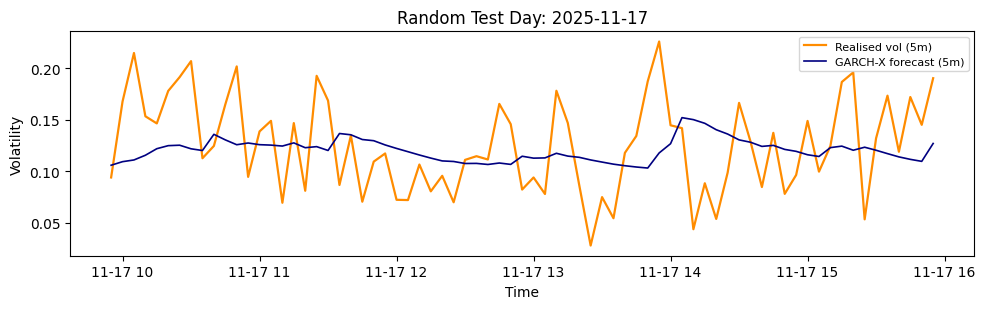

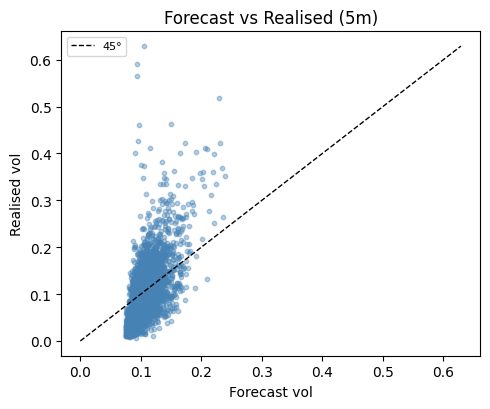

In [9]:
from matplotlib import pyplot as plt

# Build Series with datetime index for per-day slicing
test_dates_idx = pd.DatetimeIndex(pd.to_datetime(test_results["date"], errors="coerce"))
train_dates_idx = pd.DatetimeIndex(pd.to_datetime(train_results["date"], errors="coerce"))

actual_test_arr = actual_test_vols.values if hasattr(actual_test_vols, 'values') else np.asarray(actual_test_vols)
actual_train_arr = actual_train_vols.values if hasattr(actual_train_vols, 'values') else np.asarray(actual_train_vols)

rv_plot = pd.Series(actual_test_arr, index=test_dates_idx)
fc_plot = pd.Series(forecast_test_vols, index=test_dates_idx)

# drop NaN pairs
valid = rv_plot.notna() & fc_plot.notna()
rv_plot = rv_plot[valid]
fc_plot = fc_plot[valid]
common_idx = rv_plot.index

# A) One random test day
test_days = pd.Index(common_idx.normalize().unique())
n_days = min(1, len(test_days))
rng = np.random.default_rng(43)
sampled_days = np.sort(rng.choice(test_days.to_numpy(), size=n_days, replace=False))

print('Random test days shown:')
for d in sampled_days:
    print(pd.Timestamp(d).date())

for d in sampled_days:
    day_mask = common_idx.normalize() == pd.Timestamp(d)
    day_idx = common_idx[day_mask]

    fig, ax = plt.subplots(figsize=(10, 3.2))
    ax.plot(day_idx, rv_plot.loc[day_idx], color='darkorange', lw=1.6, label='Realised vol (5m)')
    ax.plot(day_idx, fc_plot.loc[day_idx], color='navy', lw=1.2, label='GARCH-X forecast (5m)')
    ax.set_title(f'Random Test Day: {pd.Timestamp(d).date()}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Volatility')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# C) Global diagnostic scatter
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.scatter(fc_plot, rv_plot, s=10, alpha=0.4, color='steelblue')
m = float(max(fc_plot.max(), rv_plot.max()))
ax.plot([0, m], [0, m], 'k--', lw=1, label='45°')
ax.set_title('Forecast vs Realised (5m)')
ax.set_xlabel('Forecast vol')
ax.set_ylabel('Realised vol')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


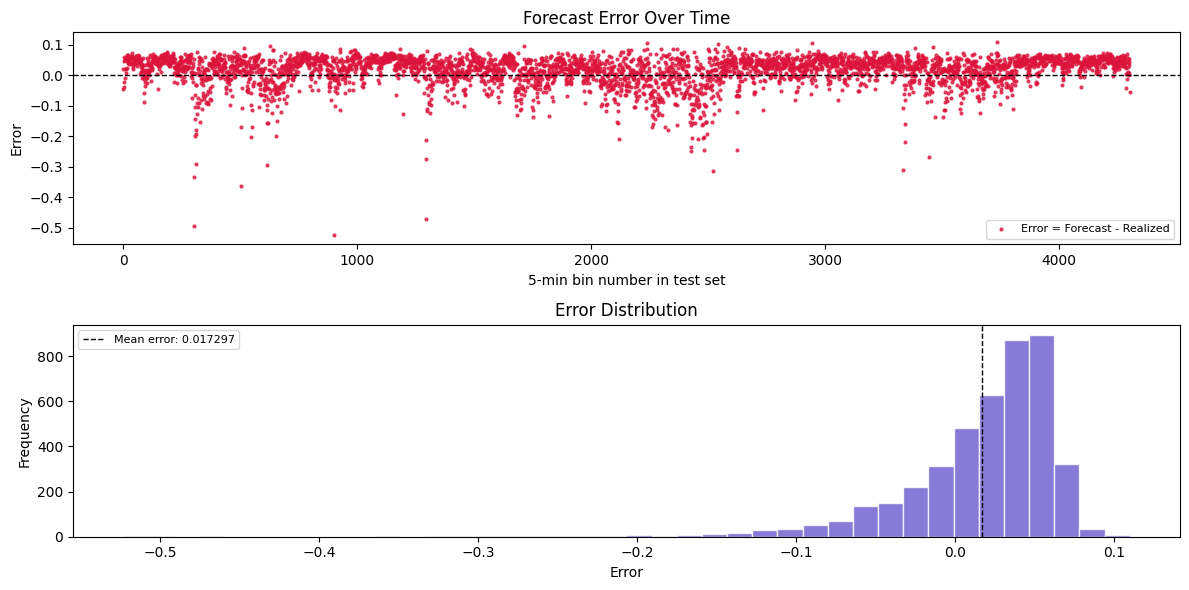

In [10]:
# Error plots: residual over time + distribution (no session gaps)
errors = fc_plot - rv_plot
err_x = np.arange(len(errors))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

# A) Error over continuous 5-min bin index
axes[0].scatter(err_x, errors.values, color='crimson', s=4, alpha=0.75, label='Error = Forecast - Realized')
axes[0].axhline(0, color='black', ls='--', lw=1)
axes[0].set_title('Forecast Error Over Time')
axes[0].set_xlabel('5-min bin number in test set')
axes[0].set_ylabel('Error')
axes[0].legend(fontsize=8)

# B) Error distribution
axes[1].hist(errors.values, bins=40, color='slateblue', alpha=0.8, edgecolor='white')
axes[1].axvline(errors.mean(), color='black', ls='--', lw=1, label=f"Mean error: {errors.mean():.6f}")
axes[1].set_title('Error Distribution')
axes[1].set_xlabel('Error')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


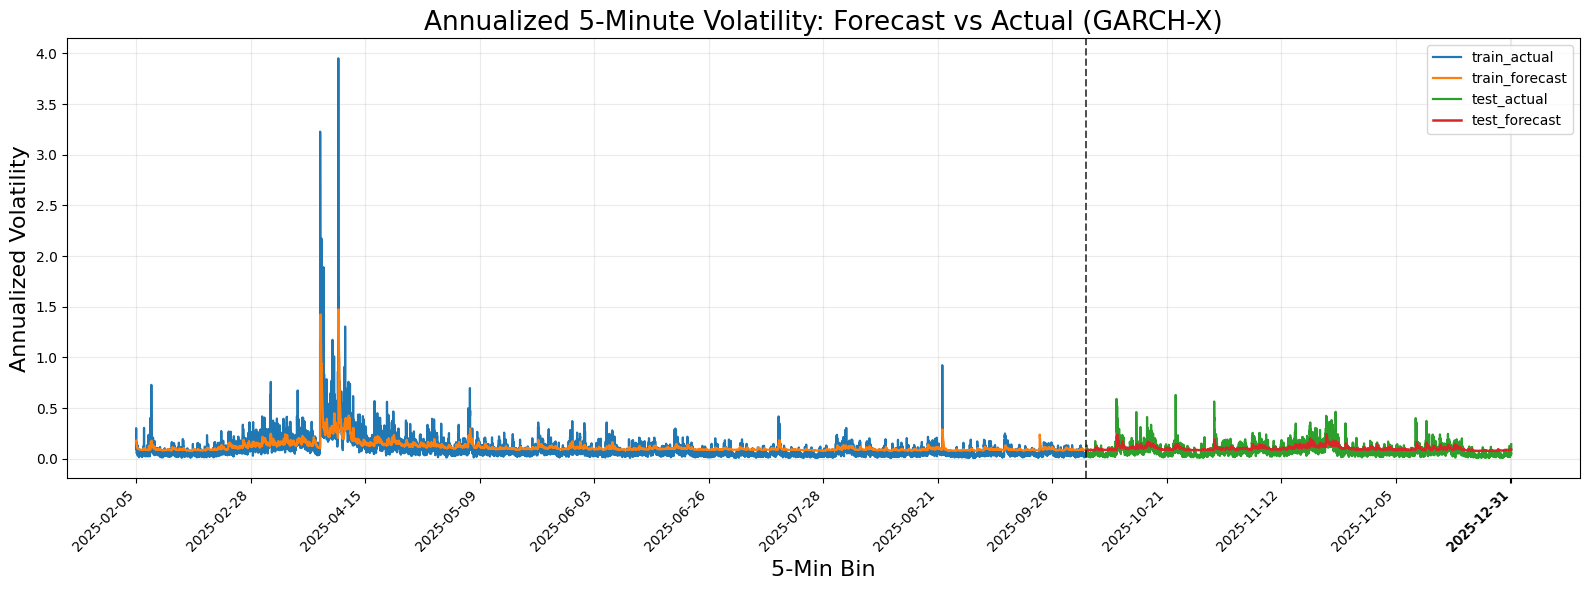

In [11]:
# Full train + test on continuous bin index with date tick labels
train_x  = np.arange(len(forecast_train_vols))
test_x   = np.arange(len(forecast_train_vols), len(forecast_train_vols) + len(forecast_test_vols))
split_x  = len(forecast_train_vols) - 0.5

all_dates = pd.concat(
    [train_dates_idx.to_series().reset_index(drop=True),
     test_dates_idx.to_series().reset_index(drop=True)],
    ignore_index=True
).dt.strftime("%Y-%m-%d")

all_x = np.arange(len(all_dates))
tick_step = max(1, len(all_x) // 12)
tick_idx = list(range(0, len(all_x), tick_step))
if tick_idx[-1] != len(all_x) - 1:
    tick_idx.append(len(all_x) - 1)

plt.figure(figsize=(16, 6))
plt.plot(train_x, actual_train_arr,      label="train_actual",    linewidth=1.6)
plt.plot(train_x, forecast_train_vols,   label="train_forecast",  linewidth=1.6)
plt.plot(test_x,  actual_test_arr,       label="test_actual",     linewidth=1.6)
plt.plot(test_x,  forecast_test_vols,    label="test_forecast",   linewidth=1.8)

plt.axvline(split_x, color="black", linestyle="--", linewidth=1.4, alpha=0.7)
plt.xticks(tick_idx, [all_dates.iloc[i] for i in tick_idx], rotation=45, ha="right")
plt.title("Annualized 5-Minute Volatility: Forecast vs Actual (GARCH-X)", fontsize=19)
plt.xlabel("5-Min Bin", fontsize=16)
plt.ylabel("Annualized Volatility", fontsize=16)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


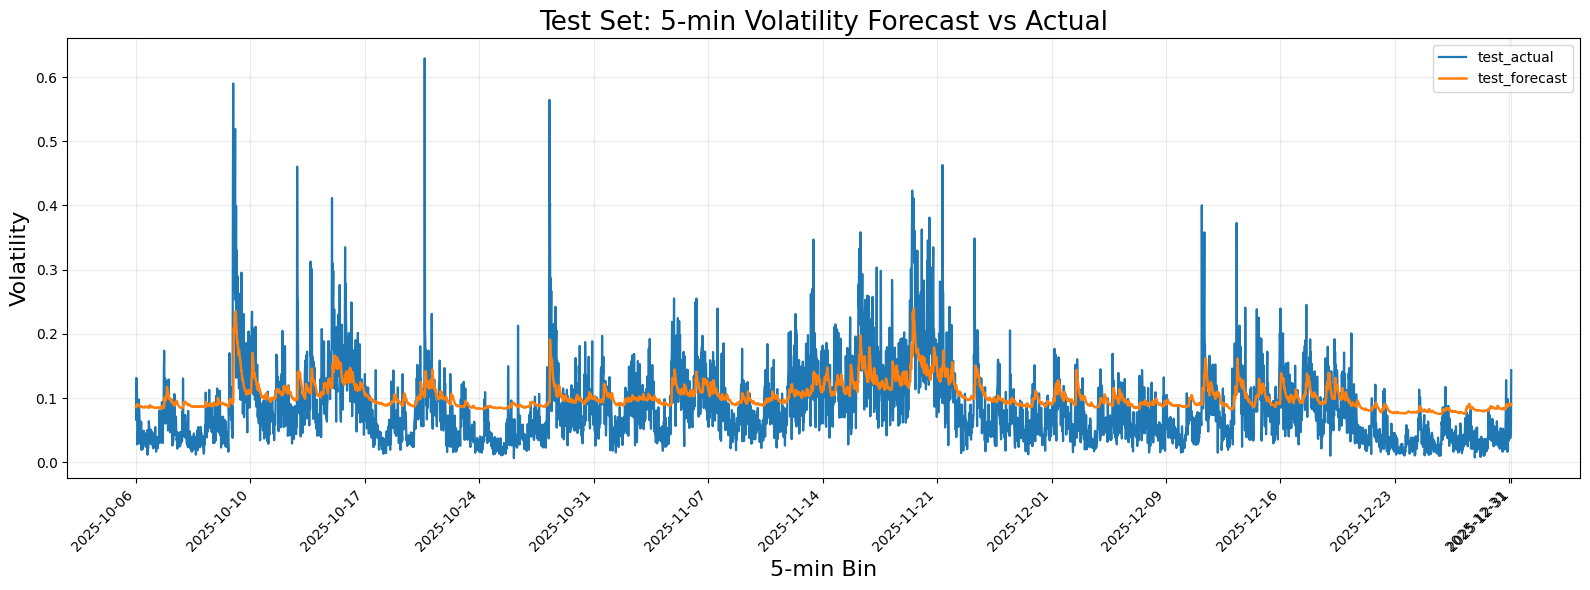

In [12]:

test_snap = pd.to_datetime(test_data["bar5"].values)

test_x_relative = np.arange(len(forecast_test_vols))

all_dates_test = list(test_snap.strftime("%Y-%m-%d"))
all_x_test = np.arange(len(all_dates_test))
tick_step = max(1, len(all_x_test) // 12)
tick_idx = list(range(0, len(all_x_test), tick_step))
if tick_idx[-1] != len(all_x_test) - 1:
    tick_idx.append(len(all_x_test) - 1)

plt.figure(figsize=(16, 6))
plt.plot(test_x_relative, actual_test_vols, label="test_actual", linewidth=1.6)
plt.plot(test_x_relative, forecast_test_vols, label="test_forecast", linewidth=1.8)

plt.xticks(tick_idx, [all_dates_test[i] for i in tick_idx], rotation=45, ha="right")
plt.title("Test Set: 5-min Volatility Forecast vs Actual", fontsize=19)
plt.xlabel("5-min Bin", fontsize=16)
plt.ylabel("Volatility", fontsize=16)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
garchx_results = test_results.copy()
garchx_results["model"] = "GARCH_X"

garchx_results = garchx_results[["date", "actual_vol", "forecast_vol", "model"]]
garchx_results["date"] = pd.to_datetime(garchx_results["date"], errors="coerce")
garchx_results = garchx_results.dropna(subset=["date", "actual_vol", "forecast_vol"])

garchx_results.to_csv("garchx_results.csv", index=False)
garchx_results.head()

,date,actual_vol,forecast_vol,model
0,2025-10-06 09:55:00,0.066537,0.086495,GARCH_X
1,2025-10-06 10:00:00,0.131296,0.087171,GARCH_X
2,2025-10-06 10:05:00,0.125065,0.087150,GARCH_X
3,2025-10-06 10:10:00,0.109859,0.089346,GARCH_X
4,2025-10-06 10:15:00,0.027804,0.088189,GARCH_X


In [14]:
train_results

,date,actual_vol,forecast_vol,error
0,2025-02-05 09:55:00,0.110181,0.177774,-0.067593
1,2025-02-05 10:00:00,0.301108,0.171356,0.129752
2,2025-02-05 10:05:00,0.114537,0.161813,-0.047276
3,2025-02-05 10:10:00,0.163087,0.156763,0.006324
4,2025-02-05 10:15:00,0.139238,0.147778,-0.008540
...,...,...,...,...
9623,2025-10-02 15:35:00,0.060708,0.085465,-0.024758
9624,2025-10-02 15:40:00,0.045145,0.085463,-0.040317
9625,2025-10-02 15:45:00,0.025070,0.086943,-0.061873
9626,2025-10-02 15:50:00,0.062959,0.086634,-0.023675


In [15]:
test_results

,date,actual_vol,forecast_vol,error
0,2025-10-06 09:55:00,0.066537,0.086495,-0.019958
1,2025-10-06 10:00:00,0.131296,0.087171,0.044125
2,2025-10-06 10:05:00,0.125065,0.087150,0.037915
3,2025-10-06 10:10:00,0.109859,0.089346,0.020512
4,2025-10-06 10:15:00,0.027804,0.088189,-0.060385
...,...,...,...,...
4298,2025-12-31 15:35:00,0.082056,0.090007,-0.007951
4299,2025-12-31 15:40:00,0.037446,0.091681,-0.054236
4300,2025-12-31 15:45:00,0.056473,0.090194,-0.033721
4301,2025-12-31 15:50:00,0.044002,0.088820,-0.044819
